In [83]:
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import Draw
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit.Chem import MACCSkeys
from rdkit.Chem.EState import Fingerprinter
from rdkit import DataStructs
from rdkit.Chem import MACCSkeys
from rdkit.Chem.Draw import SimilarityMaps

In [84]:
import matplotlib.pyplot as plt
from IPython.display import display

10.化学转换

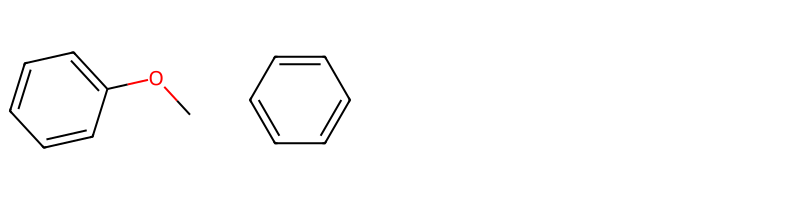

In [85]:
# 删除子结构 AllChem.DeleteSubstructs(m,patt)
m = Chem.MolFromSmiles('c1ccccc1OC')

# 定义要匹配并删除的子结构（SMARTS模式）
patt = Chem.MolFromSmarts('OC')
m2=AllChem.DeleteSubstructs(m,patt)

mols=[m,m2]
Draw.MolsToGridImage(mols,molsPerRow=4,subImgSize=(200,200),legends=['' for x in mols])

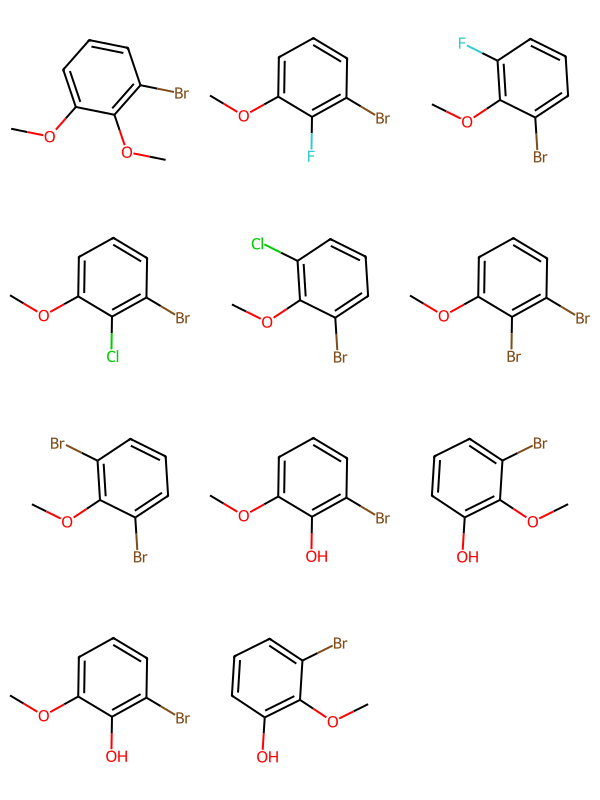

In [86]:
# 取代基替换 AllChem.ReplaceSubstructs(m,patt,repl)
m = Chem.MolFromSmiles('COc1c(Br)cccc1OC')

# 定义要被替换的【目标子结构】：OC (匹配 -OCH3 基团)
patt = Chem.MolFromSmarts('OC')
# 定义替换基团列表：依次用 F、Cl、Br、O 替换掉 OC
repsmis= ['F','Cl','Br','O']

template = Chem.MolFromSmiles('c1ccccc1')
AllChem.Compute2DCoords(template)

mols=[]
mols.append(m)

for r in repsmis:
    rep = Chem.MolFromSmarts(r)
    res = AllChem.ReplaceSubstructs(m,patt,rep)
    mols.extend(res)
for mol in res:
    AllChem.GenerateDepictionMatching2DStructure(mol, template)  # 对齐模板
    mols.append(mol)

#转成SMILES再转回分子（去重、标准化结构，避免显示异常）
smis = [ Chem.MolToSmiles(mol)      for mol in mols]
mols = [Chem.MolFromSmiles(smi)  for smi in smis]

Draw.MolsToGridImage(mols,molsPerRow=3,subImgSize=(200,200),legends=['' for x in mols])

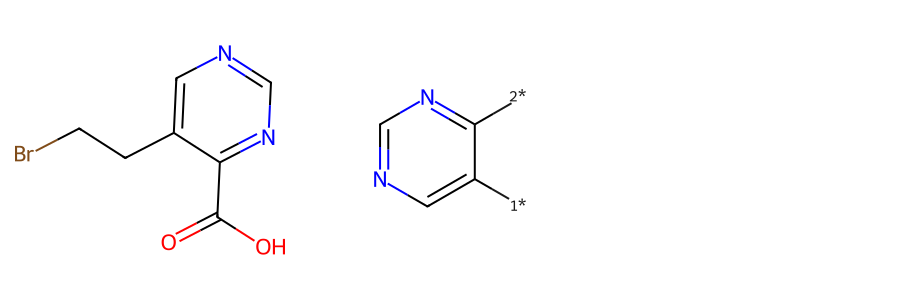

In [87]:
# SAR分析——core可视化 Chem.ReplaceSidechains(m1,core) 通过RDKit可以对其骨架可视化
m1 = Chem.MolFromSmiles('BrCCc1cncnc1C(=O)O')
mols = [m1]
# 定义嘧啶为核心结构。杂环母核：c1cncnc1
core = Chem.MolFromSmiles('c1cncnc1')
tmp = Chem.ReplaceSidechains(m1,core)

# 把替换后的分子添加到列表中
mols.append(tmp)

Draw.MolsToGridImage(mols, molsPerRow=3, subImgSize=(300,300))

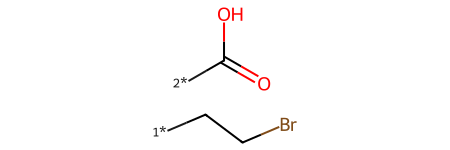

In [88]:
# SAR分析——sidechain可视化 Chem.ReplaceCore(m1,core) 通过RDKit可以对其侧链可视化
m1 = Chem.MolFromSmiles('BrCCc1cncnc1C(=O)O')

# 定义嘧啶为核心结构。杂环母核：c1cncnc1
core = Chem.MolFromSmiles('c1cncnc1')
tmp = Chem.ReplaceCore(m1,core)
tmp

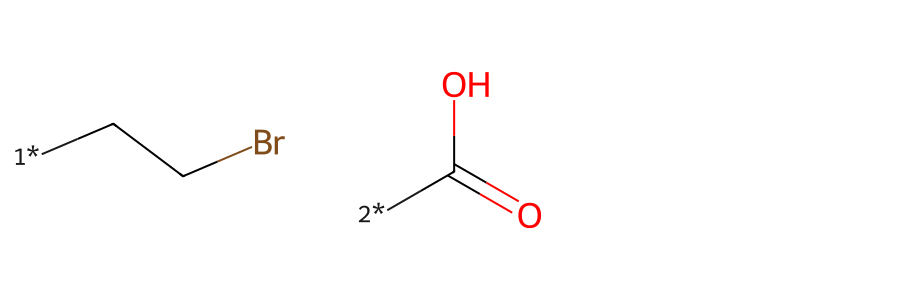

In [89]:
# 拆分片段 Chem.GetMolFrags(tmp,asMols=True)
rs = Chem.GetMolFrags(tmp,asMols=True)
Draw.MolsToGridImage(rs, molsPerRow=3, subImgSize=(300,300))


In [ ]:
# 获取分子骨架 Murcko Decomposition
"""
把分子中环结构提取出来，然后保留连接环结构的最少的键，
如果该结构上的原子直接相连双键， 则保留双键，得到的结构称为Murcko骨架。
"""
from rdkit.Chem.Scaffolds import MurckoScaffold

m1 = Chem.MolFromSmiles('C=CC(=O)N1CCC(CC1)C2CCNC3=C(C(=NN23)C4=CC=C(C=C4)OC5=CC=CC=C5)C(=O)N')
m2 = Chem.MolFromSmiles('CCC(CC)COC(=O)C(C)NP(=O)(OCC1C(C(C(O1)(C#N)C2=CC=C3N2N=CN=C3N)O)O)OC4=CC=CC=C4')
m3= Chem.MolFromSmiles('CNC1(CCCCC1=O)C1=CC=CC=C1Cl')

core_m1 = MurckoScaffold.GetScaffoldForMol(m1)
core_m2 = MurckoScaffold.GetScaffoldForMol(m2)
core_m3 = MurckoScaffold.GetScaffoldForMol(m3)
core_mols=[core_m1,core_m2,core_m3,m1,m2,m3]

Draw.MolsToGridImage(core_mols,molsPerRow=3,subImgSize=(300,300),legends=['' for x in core_mols])

11.指纹和相似性

In [91]:
# 拓扑指纹 Chem.RDKFingerprint(x)
ms = [Chem.MolFromSmiles('CCOC'), Chem.MolFromSmiles('CCO'), Chem.MolFromSmiles('COC')]
fps = [Chem.RDKFingerprint(x) for x in ms]

# MACCS 指纹MACCSkeys.GenMACCSKeys(mol)
from rdkit.Chem import MACCSkeys
fps = [MACCSkeys.GenMACCSKeys(x) for x in ms]

# 摩根指纹（圆圈指纹）AllChem.GetMorganFingerprint(mol,2)
# 摩根指纹又称为圆圈指纹。 产生摩根指纹的时候，需要指定指纹的半径，半径越大，指纹包含的信息越多。
m1 = Chem.MolFromSmiles('Cc1ccccc1')
fp1 = AllChem.GetMorganFingerprint(m1,2)

# ESTATE指纹
from rdkit.Chem.EState import Fingerprinter
mol = Chem.MolFromSmiles('CCCCOCC')
arr=Fingerprinter.FingerprintMol(mol)[0]

[20:56:20] DEPRECATION WARNING: please use MorganGenerator


In [ ]:
# 基于指纹计算相似性

# 比较下面3个分子的相似性    
m1 = Chem.MolFromSmiles('CC(=O)CC(C1=CC=C(C=C1)[N+]([O-])=O)C1=C(O)C2=CC=CC=C2OC1=O')
m2 = Chem.MolFromSmiles('CC(=O)CC(C1=CC=CC=C1)C1=C(O)C2=C(OC1=O)C=CC=C2')
m3 = Chem.MolFromSmiles('CCC(C1=CC=CC=C1)C1=C(O)C2=C(OC1=O)C=CC=C2')
mols = [m1,m2,m3]

Draw.MolsToGridImage(mols,molsPerRow=3,subImgSize=(300,300),legends=['' for x in mols])

In [93]:
# 方案一：基于拓扑指纹和 Tanimoto 相似性方法（默认） 
from rdkit import DataStructs

mols = []
for smi in smis:
    m = Chem.MolFromSmiles(smi)
    mols.append(m)

fps = [Chem.RDKFingerprint(x) for x in mols]
sm01=DataStructs.FingerprintSimilarity(fps[0],fps[1])
sm02=DataStructs.FingerprintSimilarity(fps[0],fps[2])
sm12=DataStructs.FingerprintSimilarity(fps[1],fps[2])

print("similarity between mol 1 and mol2: %.2f"%sm01)
print("similarity between mol 1 and mol3: %.2f"%sm02)
print("similarity between mol 2 and mol3: %.2f"%sm12)
# 相似性表明发现分子1 和分子3 差异最大

similarity between mol 1 and mol2: 0.41
similarity between mol 1 and mol3: 0.43
similarity between mol 2 and mol3: 0.66


In [94]:
# 方案二： 基于 MACCS 指纹和 Dice 相似性方法计算相似性
from rdkit.Chem import MACCSkeys

mols =[]
for smi in smis:
    m = Chem.MolFromSmiles(smi)
    mols.append(m)


fps = [MACCSkeys.GenMACCSKeys(x) for x in mols]
sm01=DataStructs.FingerprintSimilarity(fps[0],fps[1],metric=DataStructs.DiceSimilarity)
sm02=DataStructs.FingerprintSimilarity(fps[0],fps[2],metric=DataStructs.DiceSimilarity)
sm12=DataStructs.FingerprintSimilarity(fps[1],fps[2],metric=DataStructs.DiceSimilarity)

print("similarity between mol 1 and mol2: %.2f"%sm01)
print("similarity between mol 1 and mol3: %.2f"%sm02)
print("similarity between mol 2 and mol3: %.2f"%sm12)
# 从相似性，我们可以看出分子2和分子3比较相似

similarity between mol 1 and mol2: 0.90
similarity between mol 1 and mol3: 0.90
similarity between mol 2 and mol3: 1.00


In [ ]:
# 获取指纹对应的结构
m = Chem.MolFromSmiles('c1cccnc1C')

# 提取【5号原子】、半径=2 的周围原子环境（片段）
env = Chem.FindAtomEnvironmentOfRadiusN(m,2,5)
amap={}
# 把这些原子组成的片段变成一个新分子 submol25
submol25=Chem.PathToSubmol(m,env,atomMap=amap)

# 提取【1号原子】、半径=1 的片段
env = Chem.FindAtomEnvironmentOfRadiusN(m,1,1)
amap={}
submol11=Chem.PathToSubmol(m,env,atomMap=amap)

# 提取【2号原子】、半径=1 的片段
env = Chem.FindAtomEnvironmentOfRadiusN(m,1,2)
amap={}
submol12=Chem.PathToSubmol(m,env,atomMap=amap)

mols=[submol25,submol11,submol12]
Draw.MolsToGridImage(mols,molsPerRow=3,subImgSize=(300,200))

In [96]:
# 可视化指纹中的bit
# rdkit.Chem.Draw.DrawMorganBit() 对摩根指纹中的bit 进行可视化。
# rdkit.Chem.Draw.DrawRDKitBit() 对拓扑指纹中的bit 进行可视化。

In [ ]:
# 1.可视化摩根指纹中的bit
mol = Chem.MolFromSmiles('c1cccnc1C')

# 初始化空字典，用于存储指纹中每个bit对应的原子环境和半径信息
bi = {}

fp = AllChem.GetMorganFingerprintAsBitVect(mol,nBits=256, radius=2, bitInfo=bi)
# print(bi)

# 选择要可视化的bit编号列表
bits =[19,64,81]
# 初始化空列表，用于存储生成的图像
imgs=[]

# 遍历每个要可视化的bit编号，使用DrawMorganBit函数生成对应的图像，并将其添加到imgs列表中
for bit in bits:
    # DrawMorganBit参数说明：
    #   mol: 原始分子
    #   bit: 要可视化的bit编号
    #   bi: 包含bit信息的字典
    # 返回值：表示该bit对应子结构的图像（SVG格式）
    mfp2_svg = Draw.DrawMorganBit(mol, bit, bi)
     # 将生成的图像添加到列表中
    imgs.append(mfp2_svg)

# 定义函数：在网格中显示多个图像
def displayimgsinrow(imgs,col=4):
    plt.figure(figsize=(20,10))
    columns = col
    # 遍历每个图像，创建子图并显示图像
    for i, image in enumerate(imgs):
        # 创建子图 (len(imgs) + columns - 1) // columns 计算所需行数（向上取整）
        ax = plt.subplot((len(imgs) + columns - 1) // columns, columns, i + 1)
        # 关闭坐标轴
        ax.set_axis_off()
        plt.imshow(image)

displayimgsinrow(imgs)
"""
蓝色: 蓝色标注说明该原子是中心原子
黄色：说明该原子是芳香原子
灰色： 说明该原子时脂肪烃原子
"""

In [ ]:
# 2.可视化拓扑指纹中的bit

#查看拓扑指纹中的有效bit
mol = Chem.MolFromSmiles('c1cccnc1C')
rdkbi = {}
rdkfp = Chem.RDKFingerprint(mol, maxPath=2, bitInfo=rdkbi)
# rdkbi

bits =[5,161,294]
imgs=[]
for bit in bits:
    mfp2_svg = Draw.DrawRDKitBit(mol, bit, rdkbi)
    imgs.append(mfp2_svg)
def displayimgsinrow(imgs,col=4):
    plt.figure(figsize=(20,10))
    columns = col
    for i, image in enumerate(imgs):
        ax = plt.subplot((len(imgs) + columns - 1) // columns, columns, i + 1)
        ax.set_axis_off()
        plt.imshow(image)
    
displayimgsinrow(imgs)

In [ ]:
from rdkit import Chem
from rdkit.Chem import DataStructs
from rdkit.Chem.Draw import SimilarityMaps, rdMolDraw2D
from rdkit.Chem import rdFingerprintGenerator
import matplotlib.pyplot as plt

# 1. 定义你的两个分子（必须有参考分子 refmol 才能算相似度）
targetmol = Chem.MolFromSmiles('COc1cccc2cc(C(=O)NCCCCN3CCN(c4cccc5nccnc54)CC3)oc21')
refmol = Chem.MolFromSmiles('CCCN(CCCCN1CCN(c2ccccc2OC)CC1)Cc1ccc2ccccc2c1')

# 2. 新版无警告 Morgan 指纹生成器
fpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
def GetMorganFingerprintNew(mol, atomId=-1):
    return fpgen.GetFingerprint(mol)

# 3. 关键：用 SimilarityMaps 生成带等高线的热图
# 必须用这个函数，而不是 Draw.MolToImage
draw2d = rdMolDraw2D.MolDraw2DCairo(900, 900)
fig, maxweight = SimilarityMaps.GetSimilarityMapForFingerprint(
    refmol,
    targetmol,
    GetMorganFingerprintNew,
    draw2d=draw2d,
    metric=DataStructs.DiceSimilarity,
    contourLines=10,  # 开启等高线（波纹效果）
    colorMap='PiYG',  # 粉-绿配色，匹配示例
    alpha=0.7         # 热图透明度
)

# 4. 保存图片（这一步才会把热图写进文件）
with open("similarity_map_final.png", "wb") as f:
    f.write(draw2d.GetDrawingText())

print("✅ 已生成带波纹的相似度热图！")

12.分子性质（描述符）

In [ ]:
# 计算分子的价电子数目
import rdkit
from rdkit.Chem.Descriptors import NumValenceElectrons
from rdkit.Chem import Descriptors

mol = Chem.MolFromSmiles("N#N")

print("the Number ValenceElectrons of mol N2 is", Descriptors.NumValenceElectrons(mol))
mol=Chem.MolFromSmiles('C(=O)=O')
print("the Number ValenceElectrons of mol CO2 is", Descriptors.NumValenceElectrons(mol))
# 1个CO2中含的价电子数为4+6×2=16个。1个N2中含的价电子数为5x2=10个。

✅ 成功！右边那种热图已经生成：RIGHT_FINAL.png


13.化学反应

In [ ]:
from rdkit.Chem import AllChem
from rdkit.Chem.Draw import ReactionToImage

# 定义函数 getrxns：根据产物 SMILES 反向推导反应物，生成反应式
def getrxns(rxn, productsmi):
    productmol = Chem.MolFromSmiles(productsmi)
    # 使用反应模板对产物进行逆合成切割，得到可能的反应物组合
    reactions = rxn.RunReactants([productmol])
    # 创建空列表，用于存储最终生成的所有反应式
    rxns = []
    # 遍历逆合成得到的每一组反应结果
    for reaction in reactions:
        smis = []
        for compound in reaction:
            smi = Chem.MolToSmiles(compound)
            smis.append(smi)

        # 用点 . 连接多个反应物，拼接成标准反应式：反应物>>产物
        rxnstr = '.'.join(smis) + '>>' + productsmi
        rxns.append(rxnstr)
    return rxns


# # 定义反应模板（SMARTS），描述反应的断键/成键规则
tem = '([Cl;H0;D1;+0:1]-[c;H0;D3;+0:2](:[c:3]):[n;H0;D2;+0:4]:[c:5])>>(C-[n;H0;D3;+0:4](:[c:5]):[c;H0;D3;+0:2](=O):[c:3]).(Cl-P(-Cl)(=O)-[Cl;H0;D1;+0:1])'
rxn = AllChem.ReactionFromSmarts(tem)
# 定义目标产物的 SMILES 字符串
productsmi = 'CC(C)(Nc1nc(Cl)c(-c2ccc(F)cc2)c(-c2ccncc2)n1)c1ccccc1'
# 调用函数，反向推导得到所有可能的反应式
reactions = getrxns(rxn, productsmi)

for reaction in reactions:
    rxn_obj = AllChem.ReactionFromSmarts(reaction)
    img = ReactionToImage(rxn_obj)
    display(img)

In [ ]:
# 化学反应高级功能 —— 保护原子
# 注意：ReactionFromSmarts 要求反应 SMARTS 字符串包含 '>>'
rxn = AllChem.ReactionFromSmarts('[O;H1:1].[N:2]>>[O:1][N:2]')
acid = Chem.MolFromSmiles('CC(=O)O')
base = Chem.MolFromSmiles('CC(=O)NCCN')
ps = rxn.RunReactants((acid, base))
print("the number of reactions", len(ps))

for products in ps:
    # products 是一个元组，包含反应生成物分子
    prod_smiles = '.'.join(Chem.MolToSmiles(p) for p in products)
    print("this reaction produces", prod_smiles)

the number of reactions 2
this reaction produces CC(=O)ON(CCN)C(C)=O
this reaction produces CC(=O)NCCNOC(C)=O


14.分子片段

In [ ]:
# 内置官能团库 Chem.FragCatalog.FragCatParams() 可以加载 RDKit 内置的官能团库，获取常见官能团的结构。
import os
from rdkit import RDConfig
from rdkit.Chem import FragmentCatalog

fName = os.path.join(RDConfig.RDDataDir, 'FunctionalGroups.txt')
print("fragment file:", fName)

fparams = FragmentCatalog.FragCatParams(1, 6, fName)

mols = []
for i in range(fparams.GetNumFuncGroups()):
    mols.append(fparams.GetFuncGroup(i))

Draw.MolsToGridImage(mols, molsPerRow=8)

In [ ]:
fcat=FragmentCatalog.FragCatalog(fparams)
fcgen=FragmentCatalog.FragCatGenerator()
m = Chem.MolFromSmiles('OCC=CC(=O)O')
fcgen.AddFragsFromMol(m,fcat)
num_entries=fcat.GetNumEntries()
print("matched the function group ids is",list(fcat.GetEntryFuncGroupIds(num_entries-1)))
fg1=fparams.GetFuncGroup(1)
fg34=fparams.GetFuncGroup(34)
print("name of group 1 ",fg1.GetProp('_Name'))
print("name of group 34 ",fg34.GetProp('_Name'))

mols=[fg1,fg34]
Draw.MolsToGridImage(mols,molsPerRow=2)

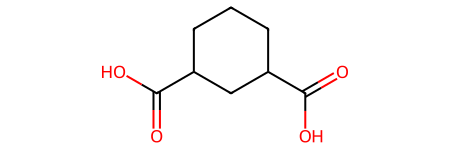

The number of the COO in the molecule is 2 


In [ ]:
# 片段统计
# 统计分子中COO片段的个数
import rdkit
from rdkit import Chem
from rdkit.Chem import Fragments
mol =Chem.MolFromSmiles('O=C(O)C1CC(C(O)=O)CCC1')
display(mol)
n=rdkit.Chem.Fragments.fr_Al_COO(mol)
print("The number of the COO in the molecule is %s "%n)